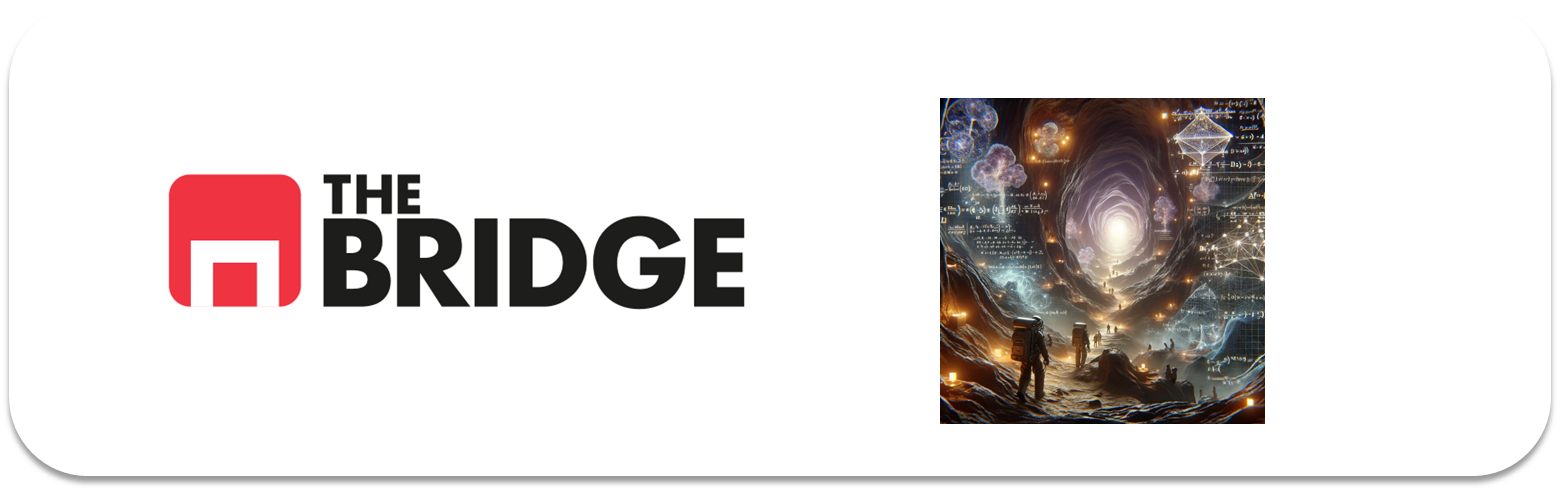

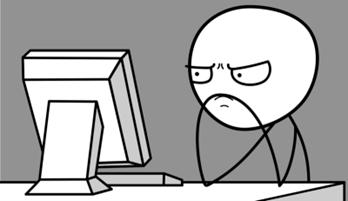

Para ejercitarte y afianzar lo aprendido sobre **Keras y DL**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Predecir eficiencia de gasolina

En este conjuntos de ejercicios vamos a trabajar sobre el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) para construir un modelo DL para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Para la construcción del modelo vamos a utilizar Keras.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Tratamiento de datos
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades de visualización del bootcamp (está en la misma carpeta que el notebook)
import bootcampviztools as bvt

# Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

# Semilla única para todo el notebook. set_random_seed fija de golpe las semillas
# de Python, NumPy y TensorFlow, así los entrenamientos son reproducibles.
SEED = 42
keras.utils.set_random_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.15.0


### Ejercicio 1

Carga los datos en un dataframe, utilizando como nombre de columnas los siguientes:

```python
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
``` 


In [2]:
# Nombres de columna que nos da el enunciado
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight",
                "Acceleration", "Model Year", "Origin"]

# El fichero no tiene cabecera y las columnas están separadas por espacios
# (uno o varios), por eso usamos sep=r"\s+".
# Ojo: al final de cada línea hay además el nombre del coche entre comillas.
# Como pandas respeta las comillas, ese nombre entra como UNA columna extra,
# así que le damos nombre ("Car Name") para poder tratarla después.
df = pd.read_csv(
    "./data/Autos_data.txt",
    sep=r"\s+",
    header=None,
    names=column_names + ["Car Name"],
)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (398, 9)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Ejercicio 2: Limpieza inicial

Echa un primer vistazo. Limpia columnas "raras". Deshazte de nulos (cuidado aquí), arregla el tipo de las features numéricas si fuera necesario. Haz una lista de las features categóricas que tuvieramos que convertir posteriormente. (Es antes del split pero no importa para este ejercicio)

In [3]:
# Primer vistazo a tipos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    str    
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car Name      398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


**Dos cosas llaman la atención en el `info()`:**

1. **`Horsepower` es de tipo texto** (`str`) cuando debería ser numérica.
2. Pandas dice que **no hay ningún nulo**... y eso es justo la trampa que avisa el enunciado.

Ambas cosas tienen la misma causa, vamos a verla.

In [4]:
# ¿Por qué Horsepower es texto? Buscamos los valores que NO son números
valores_raros = [v for v in df["Horsepower"].unique() if not str(v).replace(".", "").isdigit()]
print("Valores no numéricos en Horsepower:", valores_raros)
print("Cuántas veces aparecen:", (df["Horsepower"] == "?").sum())

Valores no numéricos en Horsepower: ['?']
Cuántas veces aparecen: 6


**Ahí está el problema:** los nulos de este dataset no vienen como `NaN`, sino escritos como
**`"?"`**. Como `"?"` es un texto perfectamente válido, pandas convierte toda la columna a texto y
`isna()` no detecta nada.

Este es el "cuidado aquí" del enunciado: **si hiciésemos `dropna()` directamente no borraríamos
nada**, porque para pandas no hay ningún nulo. Primero hay que convertir la columna a numérica
(los `"?"` se convertirán en `NaN` de verdad) y después ya podemos eliminarlos.

In [5]:
# 1) Convertimos Horsepower a numérica.
#    errors="coerce" hace que lo que no se pueda convertir (los "?") pase a ser NaN.
df["Horsepower"] = pd.to_numeric(df["Horsepower"], errors="coerce")

print("Nulos DESPUÉS de convertir:")
print(df.isna().sum()[df.isna().sum() > 0])

Nulos DESPUÉS de convertir:
Horsepower    6
dtype: int64


In [6]:
# 2) Eliminamos la columna "rara": el nombre del coche.
#    Es un identificador de texto casi único (no aporta nada al modelo y no se puede escalar).
print("Valores únicos de Car Name:", df["Car Name"].nunique(), "sobre", len(df), "filas")

df = df.drop(columns="Car Name")

# 3) Ahora sí, eliminamos las filas con nulos (solo son 6 de 398, no merece la pena imputar)
filas_antes = len(df)
df = df.dropna()
print("\nFilas eliminadas por nulos:", filas_antes - len(df))
print("Dimensiones finales:", df.shape)

Valores únicos de Car Name: 305 sobre 398 filas

Filas eliminadas por nulos: 6
Dimensiones finales: (392, 8)


In [7]:
# 4) Lista de las features categóricas que habrá que convertir más adelante.
#    Origin viene como número (1, 2, 3) pero NO es una cantidad: es un código de país.
#    Si lo dejásemos como número, el modelo pensaría que Japón (3) es "el triple" que USA (1),
#    lo cual no tiene ningún sentido.
features_categoricas = ["Origin"]
print("Features categóricas a convertir:", features_categoricas)

df.info()

Features categóricas a convertir: ['Origin']
<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Origin        392 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 27.6 KB


### Ejercicio 3

Antes de seguir nos informan que las etiquetas de "origin" correspoden a  USA para el 1, Europa para el 2 y Japón para el 3. Convierte origin a esos valores porque queremos tener el literal. Luego haz directamente un one-hot encoding de esas variable.  

*NOTA: Realmente los one-hot-encoding se pueden hacer contra el dataset original desde el principio (no afectan unos a otros), si nos los hacemos es porque hasta que no se han analizado las variables puede que no tengamos claro que queremos hacer si una codificación ordinal, una vectorización (onehot) o bien queremos hacer otro cambio en la variable y esos vienen dados por la relación de la categórica con el target y por tanto sólo se pueden ver en el train. Pero si por lo que sea sabemos seguros que vamos a hacer vectorización no hay problema en hacerlo antes del split. Por otro lado, siempre conviene quedarse con una categoria unkown para valores que pueden llegar en el futuro antes de un recalibrado.*


In [8]:
# Convertimos los códigos numéricos de Origin a su literal
df["Origin"] = df["Origin"].map({1: "USA", 2: "Europa", 3: "Japón"})

print(df["Origin"].value_counts())

Origin
USA       245
Japón      79
Europa     68
Name: count, dtype: int64


In [9]:
# One-hot encoding de Origin: crea una columna 0/1 por cada país
df = pd.get_dummies(df, columns=["Origin"], dtype=int)

print("Dimensiones tras el one-hot:", df.shape)
df.head()

Dimensiones tras el one-hot: (392, 10)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_Europa,Origin_Japón,Origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0,1


> **Nota sobre `drop_first`:** aquí **no** usamos `drop_first=True`. En un modelo lineal conviene
> quitar una columna para evitar la multicolinealidad, pero en una red neuronal no es necesario y
> además así las tres categorías quedan explícitas y el modelo las trata por igual.
>
> El enunciado también menciona que en un caso real convendría reservar una categoría `unknown` para
> países que pudieran aparecer en el futuro. Aquí no lo hacemos porque sabemos que el dataset solo
> tiene estos tres.

### Ejercicio 4

Divide los datos en train y test. Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo. Emplea una variable target para guardar el nombre de la columna target.

NOTA: El resultado tienen que ser dos datasets

In [10]:
# Guardamos el nombre del target en una variable
target = "MPG"

# Split 80% train / 20% test.
# El resultado son DOS DATASETS completos (con el target dentro), como pide el enunciado.
train_dataset, test_dataset = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
)

print("Train:", train_dataset.shape)
print("Test :", test_dataset.shape)

Train: (313, 10)
Test : (79, 10)


### Ejercicio 5

Inspecciona los datos. Revisa rápidamente la distribución conjunta del dataset de entrenamiento mediante un grid de gráficos

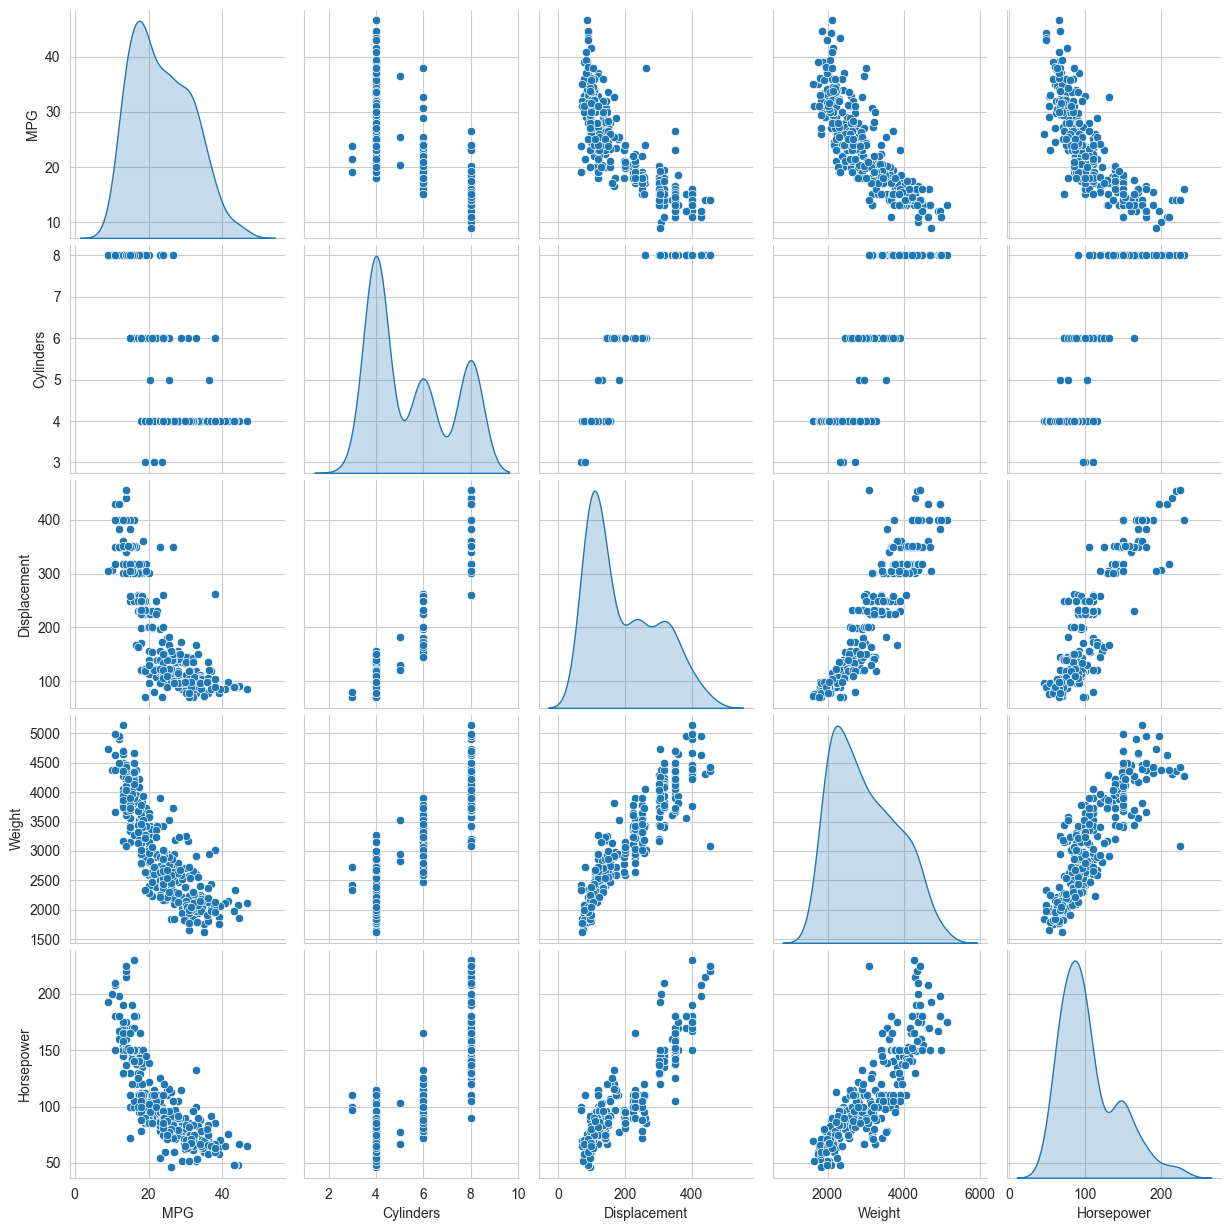

In [11]:
# Distribución conjunta de las variables numéricas principales.
# El pairplot nos da un grid: en la diagonal la distribución de cada variable
# y fuera de ella la relación entre cada par.
sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight", "Horsepower"]],
    diag_kind="kde",
)
plt.show()

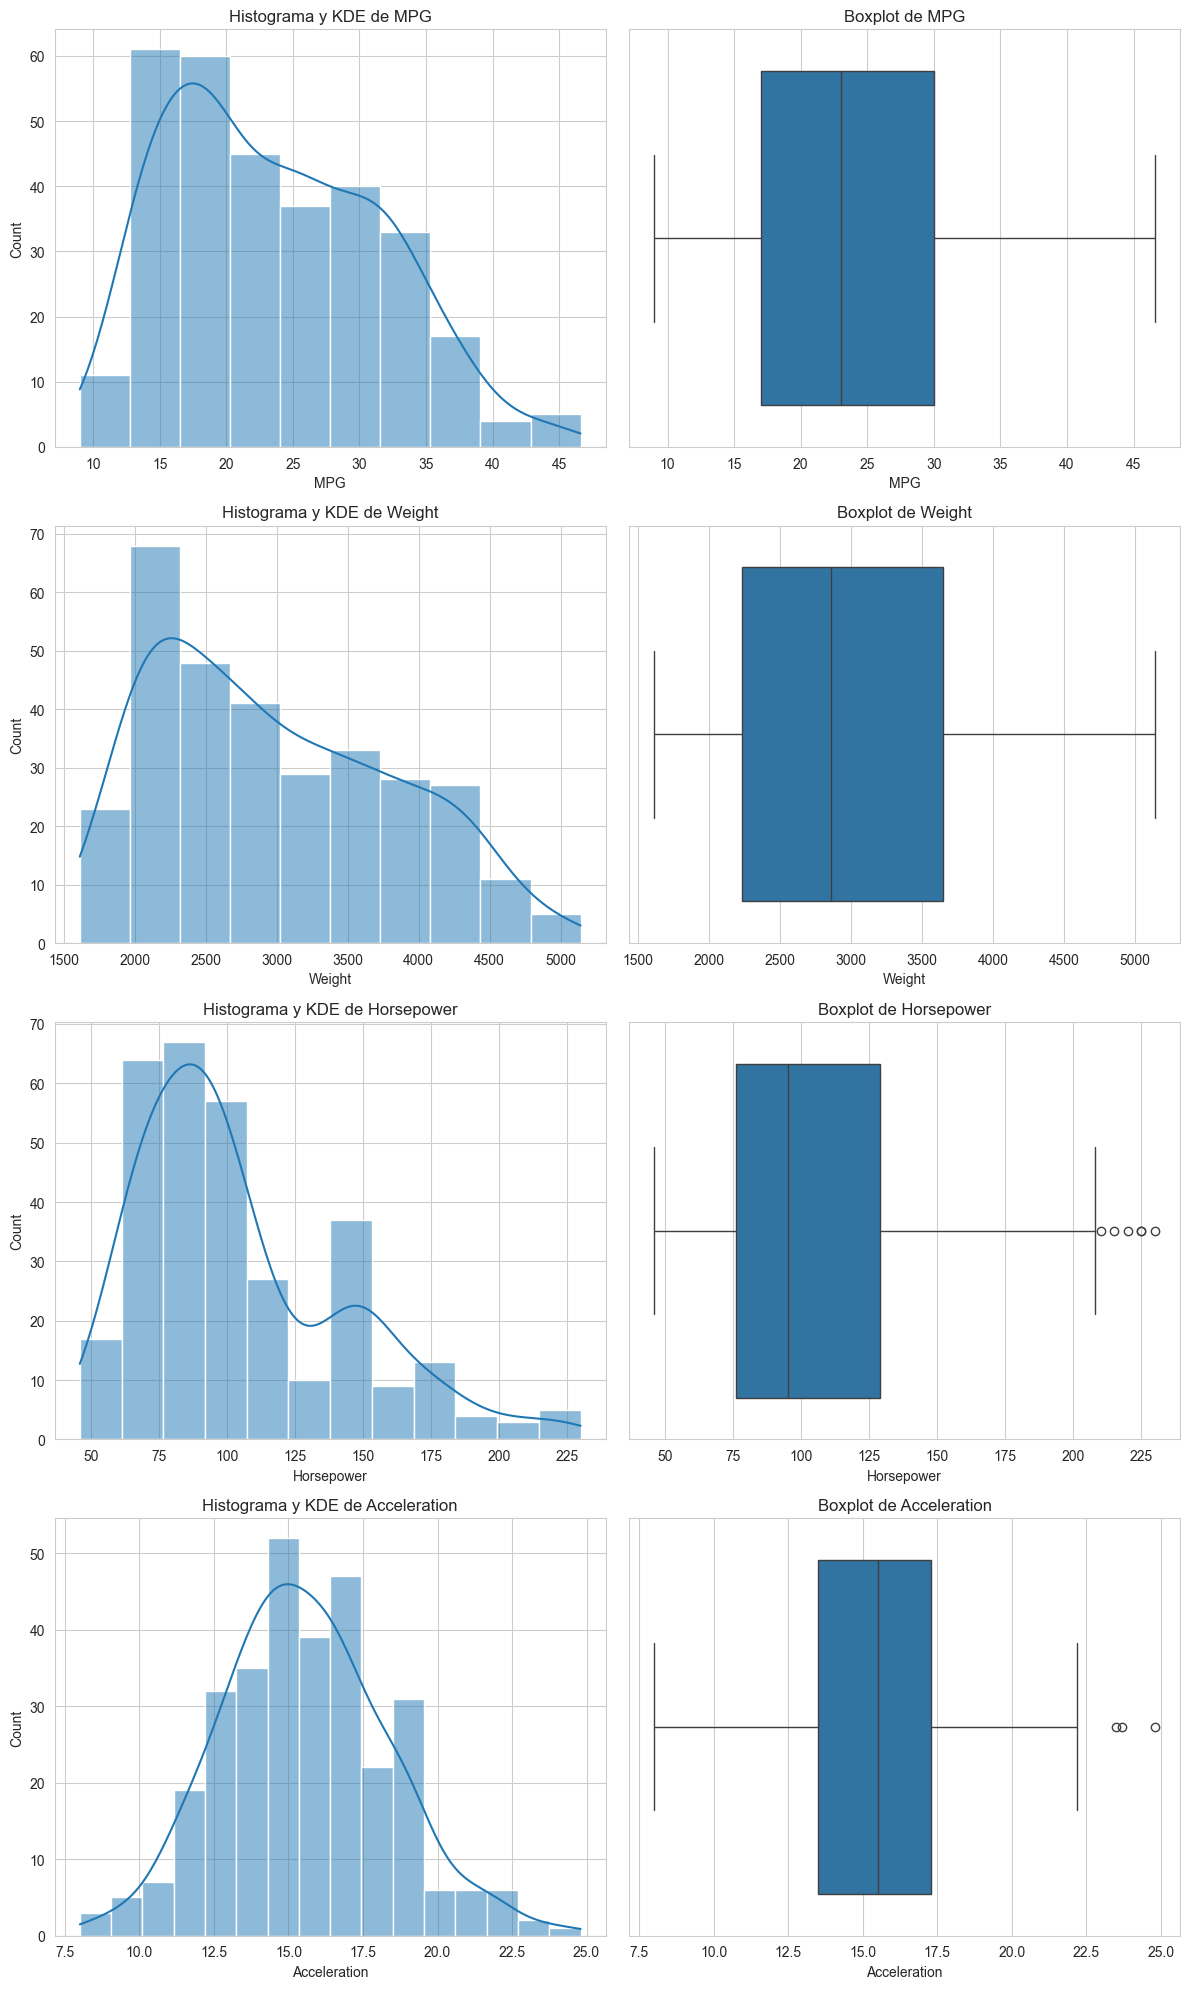

In [12]:
# Complementamos con las distribuciones individuales usando la función del bootcamp:
# para cada variable pinta un histograma con KDE y un boxplot al lado.
bvt.plot_combined_graphs(train_dataset, ["MPG", "Weight", "Horsepower", "Acceleration"])

**Qué vemos en el análisis:**

- **`Weight`, `Displacement`, `Horsepower` y `Cylinders` están fuertemente relacionadas con `MPG`,
  y además de forma negativa**: cuanto más pesa el coche y más potencia tiene, menos millas hace por
  galón. Es exactamente lo que dice la intuición.
- La relación **no es del todo lineal**: en el pairplot de `Weight` contra `MPG` se aprecia una
  curva. Esto es buena noticia para nosotros, porque es justo el tipo de patrón que una red neuronal
  puede capturar mejor que una regresión lineal.
- Esas cuatro variables están **muy correlacionadas entre sí** (un coche pesado suele tener motor
  grande y muchos cilindros). En un modelo lineal esto sería multicolinealidad y habría que tratarlo;
  en una red neuronal no es un problema grave.
- **`MPG`** tiene una distribución con una ligera asimetría a la derecha y no presenta outliers
  preocupantes.

### Ejercicio 6 

Independientemente de lo que hayas encontrado en el análisis anterior, vamos a utilizar todas las features y antes las vamos a escalar. Estandardiza train y test.

In [13]:
# Separamos features (X) y target (y) en train y test
X_train = train_dataset.drop(columns=target)
y_train = train_dataset[target]

X_test = test_dataset.drop(columns=target)
y_test = test_dataset[target]

# Estandarizamos: ajustamos el scaler SOLO con train y transformamos ambos.
# Si lo ajustásemos con todo el dataset estaríamos filtrando información del
# test al entrenamiento (data leakage).
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)
print("\nMedia por feature tras escalar:", np.round(X_train_scaled.mean(axis=0), 3))
print("Desv. típica por feature tras escalar:", np.round(X_train_scaled.std(axis=0), 3))

X_train: (313, 9) | X_test: (79, 9)

Media por feature tras escalar: [ 0.  0. -0.  0.  0. -0. -0. -0.  0.]
Desv. típica por feature tras escalar: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## El modelo

### Ejercicio 7: Construye el modelo con Keras

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Es decir una MLP con dos capas ocultas.

Por tanto, tendrá tres capas. Una inicial con activación relu (usa el argumento `input_shape` para darle el número de features). Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres interesantes para las dos primeras capas (NOTA: En este caso partimos de pocas features, por lo que puede ser interesante poner 2 o 3 como mínimo el número de features para poder obtener unas pseudofeatures que intenten capturar las interrelaciones.)

Otros datos:

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

Utiliza una aproximación en prisma (mismo numero de unidades en las capas ocultas)

In [14]:
# Número de features de entrada (lo necesitamos para el input_shape)
n_features = X_train_scaled.shape[1]
print("Número de features de entrada:", n_features)

# Construimos el modelo con la API Sequential.
# Topología en PRISMA: las dos capas ocultas tienen el mismo número de neuronas.
# Elegimos 32 neuronas siguiendo la pista del enunciado: con 9 features,
# 2-3 veces ese número serían 18-27, así que 32 es un valor redondo algo por encima.
def construye_modelo():
    """
    Crea y compila el MLP de regresión.

    Lo metemos en una función porque en el Ejercicio 12 tendremos que volver a
    construirlo desde cero (si reutilizásemos el modelo ya entrenado, el fit
    continuaría donde lo dejó y el callback no serviría de nada).

    Retorna:
        keras.Sequential: el modelo ya compilado y listo para entrenar.
    """
    modelo = keras.Sequential([
        # Capa oculta 1: recibe las features (input_shape) y activación relu
        keras.layers.Dense(32, activation="relu", input_shape=(n_features,)),
        # Capa oculta 2: mismo número de neuronas (prisma)
        keras.layers.Dense(32, activation="relu"),
        # Capa de salida: UNA sola neurona y SIN activación, porque es regresión
        # (queremos un número continuo, no una probabilidad)
        keras.layers.Dense(1),
    ])

    modelo.compile(
        loss="mse",                                  # lo que se minimiza
        optimizer=keras.optimizers.RMSprop(0.001),   # optimizador que pide el enunciado
        metrics=["mae", "mse"],                      # lo que vigilamos nosotros
    )
    return modelo


model = construye_modelo()
print("Modelo construido y compilado")

Número de features de entrada: 9


Modelo construido y compilado


### Ejercicio 8

Inspecciona el modelo usando el método `.summary` para imprimir una descripción simple del modelo

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 9 Entrenar el modelo

Entrena el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

In [16]:
# Entrenamos 1000 epochs reservando un 20% de train para validación.
# verbose=0 evita que se impriman 1000 líneas por pantalla; el histórico
# queda igualmente guardado en "history".
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=1000,
    validation_split=0.2,
    verbose=0,
)

print("Entrenamiento terminado. Epochs ejecutadas:", len(history.history["loss"]))

Entrenamiento terminado. Epochs ejecutadas: 1000


### Ejercicio 10

Visualiza el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`. Muestra la evolución del error en train y validation por un lado, y la evolución de la pérdida (loss), también train contra validation, en otra.

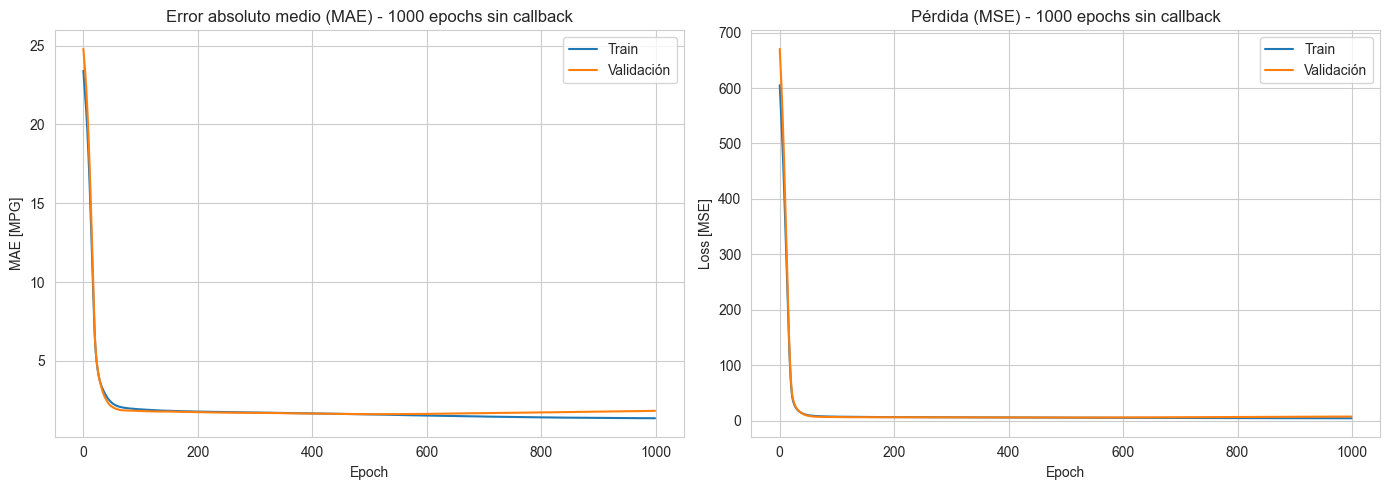

In [17]:
# Pasamos el histórico a un DataFrame, que es mucho más cómodo de manejar
hist = pd.DataFrame(history.history)
hist["epoch"] = hist.index

# Creamos una función auxiliar porque vamos a pintar estas mismas gráficas
# otra vez en el Ejercicio 12.
def pinta_historico(hist, titulo=""):
    """
    Pinta la evolución del MAE y de la pérdida (MSE), en train y en validación.

    Argumentos:
        hist (pd.DataFrame): histórico del entrenamiento con las columnas
            mae, val_mae, loss y val_loss.
        titulo (str): texto adicional para el título de las gráficas.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfica 1: error absoluto medio (MAE)
    axes[0].plot(hist["epoch"], hist["mae"], label="Train")
    axes[0].plot(hist["epoch"], hist["val_mae"], label="Validación")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MAE [MPG]")
    axes[0].set_title("Error absoluto medio (MAE) " + titulo)
    axes[0].legend()

    # Gráfica 2: pérdida (MSE), que es lo que realmente se minimiza
    axes[1].plot(hist["epoch"], hist["loss"], label="Train")
    axes[1].plot(hist["epoch"], hist["val_loss"], label="Validación")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss [MSE]")
    axes[1].set_title("Pérdida (MSE) " + titulo)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


pinta_historico(hist, "- 1000 epochs sin callback")

### Ejercicio 11

Comenta las gráficas anteriores.

In [18]:
# Sacamos algunos números que nos ayuden a comentar las gráficas
epoch_mejor = hist["val_loss"].idxmin()

print("Mejor epoch según val_loss:", epoch_mejor, "de", len(hist))
print()
print("En la MEJOR epoch ({}):".format(epoch_mejor))
print("  MAE train      : {:.3f}".format(hist.loc[epoch_mejor, "mae"]))
print("  MAE validación : {:.3f}".format(hist.loc[epoch_mejor, "val_mae"]))
print()
print("Al FINAL (epoch {}):".format(len(hist) - 1))
print("  MAE train      : {:.3f}".format(hist["mae"].iloc[-1]))
print("  MAE validación : {:.3f}".format(hist["val_mae"].iloc[-1]))
print()
print("Diferencia val - train al final: {:.3f} MPG".format(
    hist["val_mae"].iloc[-1] - hist["mae"].iloc[-1]))

Mejor epoch según val_loss: 432 de 1000

En la MEJOR epoch (432):
  MAE train      : 1.646
  MAE validación : 1.642

Al FINAL (epoch 999):
  MAE train      : 1.359
  MAE validación : 1.833

Diferencia val - train al final: 0.474 MPG


### Comentario de las gráficas (Ejercicio 11)

**Lo primero que salta a la vista: el modelo está sobreajustando.**

- Durante las **primeras ~50 epochs** ambas curvas bajan en picado y muy juntas. El modelo está
  aprendiendo de verdad.
- A partir de ahí las curvas **se separan**: la de train sigue bajando poco a poco, mientras que la
  de validación se estanca e incluso empieza a subir ligeramente. Esa **separación entre las dos
  curvas es la firma clásica del overfitting**: el modelo ya no está aprendiendo patrones generales,
  está memorizando los datos de entrenamiento.
- La curva de validación además es **muy ruidosa**, con picos bruscos. Es normal: el set de
  validación es pequeño (un 20% de 313 filas son unas 63 muestras), así que cada epoch varía bastante.

**La conclusión práctica:** entrenar 1000 epochs es **desperdiciar tiempo y además empeorar el
modelo**. El mejor momento para haber parado fue mucho antes, tal como indica la epoch de `val_loss`
mínimo que hemos calculado arriba. Todo lo que viene después es entrenamiento que no solo no aporta,
sino que resta capacidad de generalización.

Esto es exactamente el problema que resuelve el **EarlyStopping** del Ejercicio 12.

### Ejercicio 12

Independientemente de lo comentado en 11, vamos a añadir un callback al entrenamiento. Para ello, construye el modelo otra vez y vuelve a compilarlo (si no lo haces, como ya sabes comenzará el entrenamiento donde lo dejó y no nos valdrá el callback para nada). Entrena el modelo con los mismos hiperparámetros del ejercicio 10 y pinta la gráfica de evolución de los errores e interprétalo (obten el MAE medio una vez "estabilizado" el entrenamiento).  

Para el earlystopping utiliza un margen de 20 epochs.

El entrenamiento se detuvo en la epoch 453 de 1000


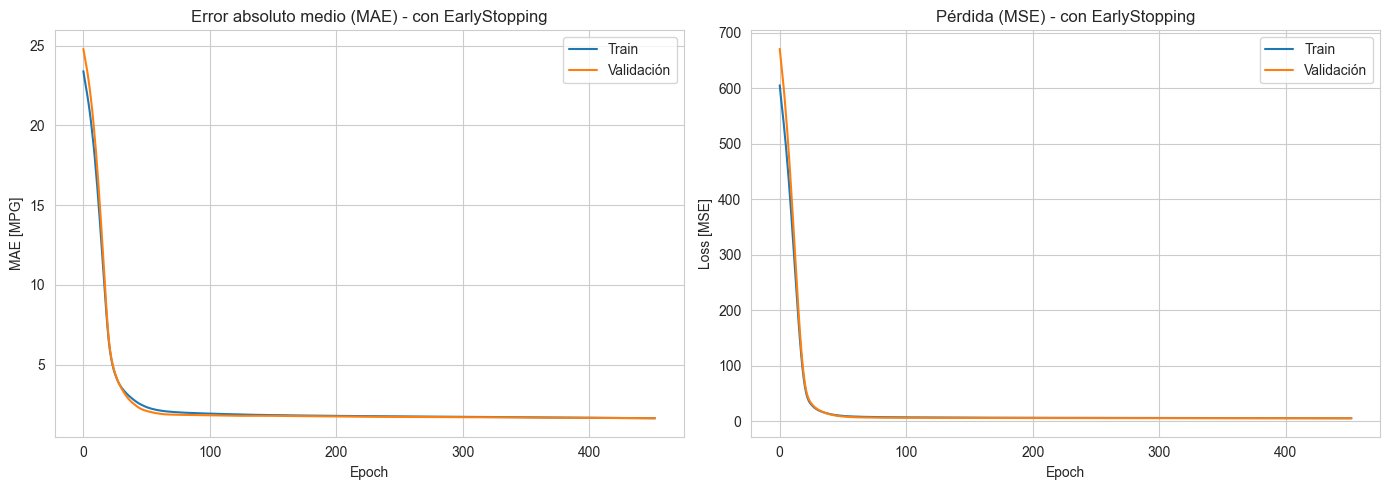

In [19]:
# IMPORTANTE: reconstruimos el modelo desde cero.
# Si reutilizásemos el "model" anterior, fit() continuaría el entrenamiento
# donde lo dejó (ya lleva 1000 epochs) y el callback no serviría de nada.
keras.utils.set_random_seed(SEED)
model_es = construye_modelo()

# EarlyStopping: para el entrenamiento cuando val_loss lleva 20 epochs sin mejorar.
#   - patience=20 -> el "margen de 20 epochs" que pide el enunciado
#   - restore_best_weights=True -> se queda con los pesos de la MEJOR epoch,
#     no con los de la última (que ya son peores). Es fácil olvidarlo.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

history_es = model_es.fit(
    X_train_scaled,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0,
)

hist_es = pd.DataFrame(history_es.history)
hist_es["epoch"] = hist_es.index

print("El entrenamiento se detuvo en la epoch {} de 1000".format(len(hist_es)))
pinta_historico(hist_es, "- con EarlyStopping")

Interpreta el gráfico

In [20]:
# MAE medio una vez "estabilizado" el entrenamiento.
# Tomamos las últimas 10 epochs como zona estable.
mae_train_estable = hist_es["mae"].tail(10).mean()
mae_val_estable = hist_es["val_mae"].tail(10).mean()

print("MAE medio en las últimas 10 epochs:")
print("  Train      : {:.3f} MPG".format(mae_train_estable))
print("  Validación : {:.3f} MPG".format(mae_val_estable))
print()
print("Recordatorio: el MPG medio del dataset es {:.1f}, ".format(df[target].mean()))
print("así que un MAE de ~{:.1f} es un error de en torno al {:.1f}%".format(
    mae_val_estable, 100 * mae_val_estable / df[target].mean()))

MAE medio en las últimas 10 epochs:
  Train      : 1.636 MPG
  Validación : 1.636 MPG

Recordatorio: el MPG medio del dataset es 23.4, 
así que un MAE de ~1.6 es un error de en torno al 7.0%


### Interpretación del gráfico (Ejercicio 12)

**El EarlyStopping ha hecho justo lo que queríamos.** El entrenamiento se ha detenido solo, mucho
antes de las 1000 epochs, en cuanto ha visto que la pérdida de validación llevaba 20 epochs sin
mejorar.

Comparando con el entrenamiento anterior:

- **Las dos curvas ahora terminan prácticamente juntas** (MAE de train y de validación casi
  idénticos), en lugar de la separación que veíamos antes. Es decir, hemos cortado justo antes de que
  el sobreajuste se hiciera grande.
- Hemos **ahorrado más de la mitad del tiempo de entrenamiento**.
- Y lo más importante: gracias a `restore_best_weights=True` **no nos quedamos con los pesos del
  final, sino con los de la mejor epoch**.

**Sobre la magnitud del error:** un MAE de aproximadamente **1,6 MPG** sobre un consumo medio de unas
23 MPG significa que nos equivocamos en torno a un **7%**. Para un dataset de menos de 400 coches y
una red tan sencilla, es un resultado más que razonable.

> **La lección:** el EarlyStopping no es solo una optimización para ahorrar tiempo, **es también una
> técnica de regularización**. Al parar antes, impide que el modelo llegue a memorizar el train.

### Ejercicio 13

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [21]:
# Evaluamos con el conjunto de TEST, que el modelo no ha visto nunca.
# evaluate devuelve, en este orden: loss (mse), mae y mse
loss, mae, mse = model_es.evaluate(X_test_scaled, y_test, verbose=0)

print("Resultados sobre el conjunto de TEST")
print("=" * 40)
print("Loss (MSE) : {:.3f}".format(loss))
print("MAE        : {:.3f} MPG".format(mae))
print("MSE        : {:.3f}".format(mse))
print()
print("Es decir, de media nos equivocamos en unas {:.2f} millas por galón.".format(mae))

Resultados sobre el conjunto de TEST
Loss (MSE) : 5.529
MAE        : 1.681 MPG
MSE        : 5.529

Es decir, de media nos equivocamos en unas 1.68 millas por galón.


**El resultado en test es coherente con lo que veíamos en validación** (un MAE en torno a 1,6-1,7
MPG), lo cual es una buena señal: significa que el modelo **generaliza bien** y que no nos hemos
engañado ajustando demasiado a la validación.

Merece la pena fijarse en un detalle: el **MSE es bastante mayor que el MAE**. Eso es normal y
esperable, porque el MSE eleva los errores al cuadrado y por tanto **castiga mucho más los fallos
grandes**. Que haya esa diferencia nos dice que el modelo acierta bien en la mayoría de coches pero
falla más en unos pocos casos concretos, que es justo lo que vamos a ver en el scatter del
Ejercicio 14.

### Ejercicio 14

Dibuja en un scatter plot las predicciones de test vs sus true labels.

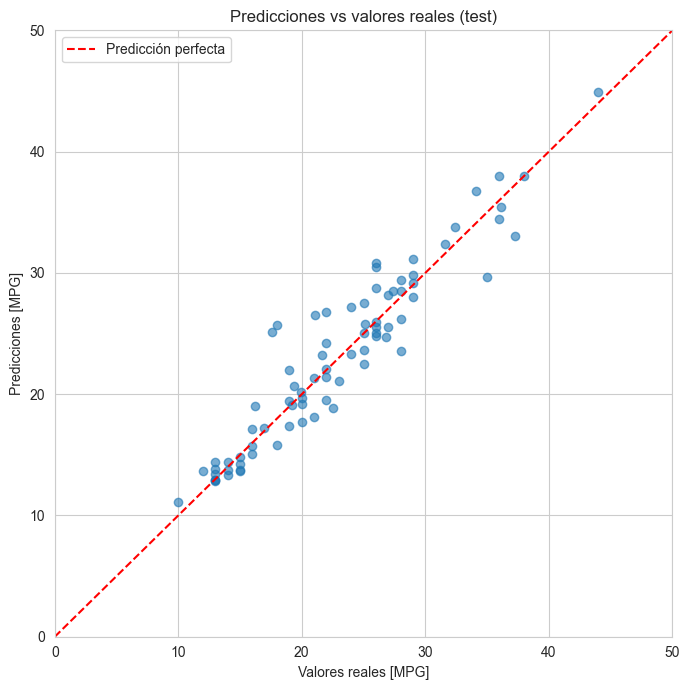

In [22]:
# Predicciones sobre test.
# flatten() convierte la salida (n, 1) en un vector plano (n,)
y_pred = model_es.predict(X_test_scaled, verbose=0).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)

# Línea diagonal: donde caerían los puntos si la predicción fuese perfecta
limites = [0, 50]
plt.plot(limites, limites, "r--", label="Predicción perfecta")

plt.xlabel("Valores reales [MPG]")
plt.ylabel("Predicciones [MPG]")
plt.title("Predicciones vs valores reales (test)")
plt.xlim(limites)
plt.ylim(limites)
plt.legend()
plt.tight_layout()
plt.show()

### Comentario final

**El modelo funciona bien.** Los puntos se agrupan de forma clara alrededor de la diagonal roja, que
es donde caerían si las predicciones fuesen perfectas.

Mirando los residuos por tramos de consumo aparece un detalle interesante:

| Tramo real (MPG) | Coches | Sesgo medio | MAE |
|---|---|---|---|
| 10 - 20 | 29 | +0,70 | 1,39 |
| 20 - 27 | 29 | +0,30 | 1,97 |
| 27 - 35 | 14 | +0,24 | 1,48 |
| **más de 35** | **7** | **-1,28** | **2,10** |

En los tres primeros tramos el modelo **predice ligeramente por encima** del valor real, pero en los
coches más eficientes (**más de 35 MPG**) se invierte: ahí **se queda corto**, con el sesgo más
grande (-1,28) y el peor error (MAE de 2,10).

**La explicación es la cantidad de datos:** en ese tramo solo hay **7 coches en test** (y pocos
también en train). Son los vehículos más eficientes, que eran una rareza en los años 70-80. Con tan
pocos ejemplos, la red apenas tiene información para aprender a predecirlos y **tiende a "tirar hacia
la media"**, que es el comportamiento típico de un modelo de regresión ante datos escasos en un
extremo del rango.

**Conclusión del ejercicio:** con un MLP de dos capas ocultas de 32 neuronas, un escalado correcto y
un EarlyStopping para no sobreentrenar, predecimos el consumo de un coche de los años 70-80 con un
error medio de **1,68 MPG**, en torno a un 7% sobre un consumo medio de 23,4 MPG.